# User Logs EDA

## 1. 샘플 데이터 불러오기

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 샘플링된 user_logs 불러오기
user_logs = pd.read_csv("../../data/sampled/user_logs_100k.csv")

print("데이터 크기:", user_logs.shape)
print("고객 수:", user_logs["msno"].nunique())

user_logs.head()

데이터 크기: (1815285, 9)
고객 수: 100000


,msno,date,num_25,num_50,num_75,num_985,num_100,num_unq,total_secs
0,6eT/NGMljpNgEeqTYIdhkc/dvUik+b+41sBNrXJ0cBQ=,20170324,78,5,3,2,8,85,3490.020
1,Q6XdUeVvsXNF/7o0IjPbcSg6dCsFlsRsdGLuiT5UIiI=,20170318,1,1,1,0,136,123,37989.716
2,xZmokPACIvbzXoCrwp+nxnB3SLiLLT+QnFy6ZOYofLE=,20170318,0,1,0,0,22,3,4194.039
3,Dde9YoZqShj9wZAgEm0mc+V995QOExh+1WRlL9oMQJg=,20170318,34,13,7,6,83,74,24825.041
4,J0BhO71yiNuIbyK+QkzR2Ih1PXarheWYO3EcZIQk5NQ=,20170316,0,0,0,0,3,3,697.004


## 1. 데이터 구조 및 품질 확인

In [30]:
user_logs.shape                        # 전체 크기 확인
user_logs.info()                       # 데이터 전체 구조 확인
user_logs.isnull().sum()               # 결측치 개수
user_logs.duplicated().sum()           # 컬럼값이 동일한 중복 행의 갯수
user_logs["msno"].nunique()            # msno 컬럼에서 서로 다른 고객 ID의 개수 확인

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1815285 entries, 0 to 1815284
Data columns (total 9 columns):
 #   Column      Dtype  
---  ------      -----  
 0   msno        object 
 1   date        int64  
 2   num_25      int64  
 3   num_50      int64  
 4   num_75      int64  
 5   num_985     int64  
 6   num_100     int64  
 7   num_unq     int64  
 8   total_secs  float64
dtypes: float64(1), int64(7), object(1)
memory usage: 124.6+ MB


100000

## 2. 수집 기간 확인

In [31]:
user_logs["date"] = pd.to_datetime(
    user_logs["date"].astype(str),
    format="%Y%m%d"
)

user_logs["date"].agg(["min", "max"])

min   2017-03-01
max   2017-03-31
Name: date, dtype: datetime64[ns]

## 3. 고객별 로그 수 분포

In [32]:
# 고객 ID별 그룹 생성
logs_per_user = user_logs.groupby("msno").size()

logs_per_user.describe()

count    100000.000000
mean         18.152850
std           9.628569
min           1.000000
25%          10.000000
50%          19.000000
75%          27.000000
max          31.000000
dtype: float64

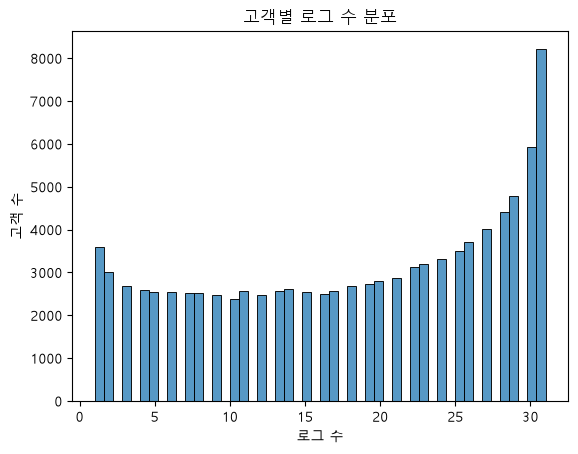

In [33]:
sns.histplot(logs_per_user, bins=50)
plt.title("고객별 로그 수 분포")
plt.xlabel("로그 수")
plt.ylabel("고객 수")
plt.show()

## 4. 날짜별 이용 고객 수

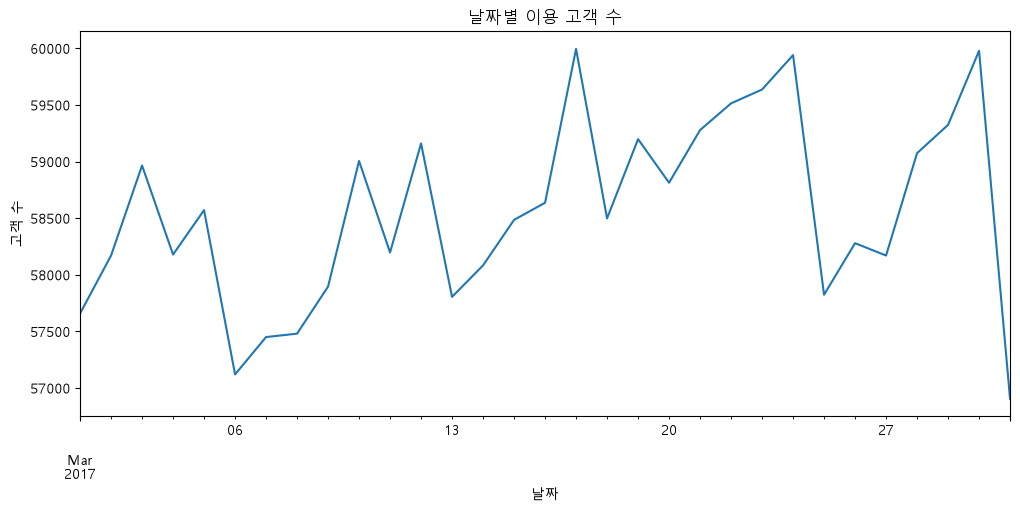

In [34]:
# 날짜별 고객 ID별 그룹 생성
daily_users = user_logs.groupby("date")["msno"].nunique()

daily_users.plot(figsize=(12, 5))
plt.title("날짜별 이용 고객 수")
plt.xlabel("날짜")
plt.ylabel("고객 수")
plt.show()

## 5. 재생 행동 통계

In [35]:
# 재생 길이별 통계
play_cols = [
    "num_25", "num_50", "num_75",
    "num_985", "num_100",
    "num_unq", "total_secs"
]

user_logs[play_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
num_25,1815285.0,5.993656,12.317383,0.000,0.000,2.000,7.000,978.000
num_50,1815285.0,1.451126,3.681234,0.000,0.000,0.000,2.000,831.000
num_75,1815285.0,0.918479,1.812747,0.000,0.000,0.000,1.000,246.000
num_985,1815285.0,1.048354,3.647019,0.000,0.000,0.000,1.000,957.000
num_100,1815285.0,29.979885,40.063497,0.000,7.000,16.000,37.000,7779.000
num_unq,1815285.0,28.581022,31.723928,1.000,8.000,18.000,37.000,1410.000
total_secs,1815285.0,7820.166348,9690.287722,0.011,1944.133,4522.426,9716.387,1588632.203


## 6. 완곡 재생 비중 확인

In [36]:
# 
user_logs["total_play_count"] = (
    user_logs["num_25"]
    + user_logs["num_50"]
    + user_logs["num_75"]
    + user_logs["num_985"]
    + user_logs["num_100"]
)

user_logs["completion_rate"] = (
    user_logs["num_100"]
    / user_logs["total_play_count"].replace(0, np.nan)
)

user_logs["completion_rate"].describe()

count    1.815285e+06
mean     7.246693e-01
std      2.598606e-01
min      0.000000e+00
25%      5.714286e-01
50%      8.000000e-01
75%      9.396552e-01
max      1.000000e+00
Name: completion_rate, dtype: float64

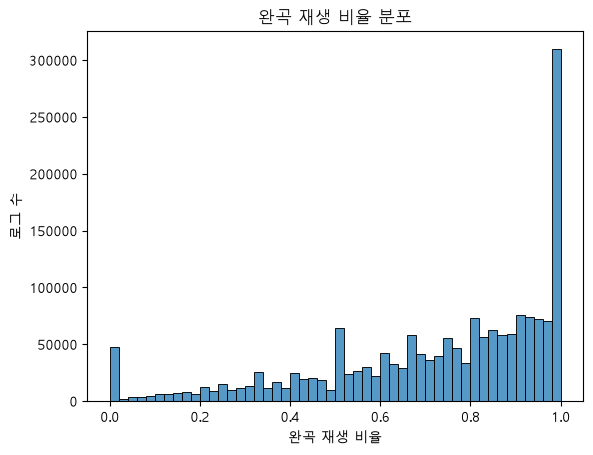

In [37]:
sns.histplot(user_logs["completion_rate"].dropna(), bins=50)
plt.title("완곡 재생 비율 분포")
plt.xlabel("완곡 재생 비율")
plt.ylabel("로그 수")
plt.show()

## 7. 재생 지표 상관관계

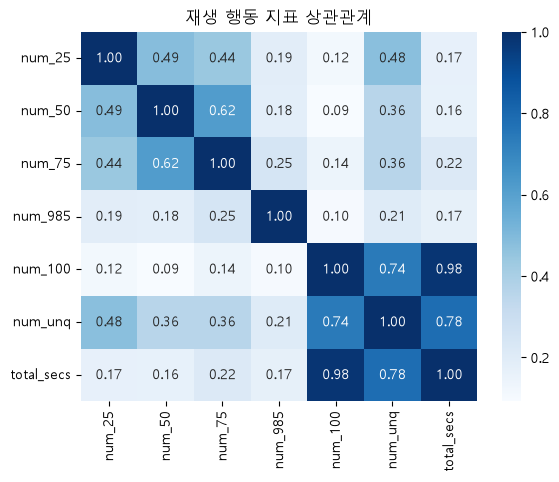

In [38]:
sns.heatmap(
    user_logs[play_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="Blues"
)
plt.title("재생 행동 지표 상관관계")
plt.show()

## 통합용 고객별 집계 데이터 생성

In [39]:
logs_agg = (
    user_logs
    .groupby("msno")
    .agg(
        activity_days=("date", "nunique"),
        total_num_100=("num_100", "sum"),
        total_num_unq=("num_unq", "sum"),
        total_secs=("total_secs", "sum")
    )
    .reset_index()
)